# ***Прогнозирование объёмов отгрузок со складов (Wildberries)***
 
## Описание задачи 

Эффективная логистика — один из ключевых факторов бесперебойной работы любого маркетплейса. Для поддержания быстрой доставки и оптимального использования автопарка необходимо заранее понимать объёмы будущих отгрузок со складов. 

**Задача:** разработать модель прогнозирования временного ряда, которая на основе исторических данных предсказывает объёмы отгрузок со складов на 8 шагов вперёд (с шагом 30 минут)

## Данные 

- `train_solo_track.parquet` - исторические данные (4.6 млн строк, 9 колонок)
- `test_solo_track.parquet` - тестовая выборка (8000 строк, только id, route_id, timestamp)

**Признаки:**
- `route_id` - идентификатор маршрута
- `timestamp` - момент времени
- `status_1, status_2, status_3` - количество товаров, направляющихся по данному маршруту, прошедших конкретные этапы обработки на текущем складе за последние 30 минут.
- `status_4, status_5, status_6` - количество товаров, направляющихся на текущий склад, прошедших конкретные этапы обработки на предыдущем складе за последние 30 минут
- `target_1h` - целевая переменная (объём отгрузок за последний час)

## Метрика 

Метрика качества - `WAPE + |Relative Bias|`. Чем меньше значение, тем лучше.

## Результат
- **Лучшая модель:** Ridge регрессия, обученная на последних 7 днях
- **Скор на публичном лидерборде:** `0.3365`
- **Скор на приватном лидерборде:** `0.3349`


# 1. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
train_df = pd.read_parquet('../data/train_solo_track.parquet')
test_df = pd.read_parquet('../data/test_solo_track.parquet')

In [4]:
train_df

,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
0,471,2025-07-28 00:00:00,13,23,45,85645,491354,487,88655
1,471,2025-07-28 00:30:00,14,18,1,80049,494754,489,223929
2,471,2025-07-28 01:00:00,8,8,38,82616,490659,487,168519
3,471,2025-07-28 01:30:00,10,2,7,80506,489967,494,111380
4,471,2025-07-28 02:00:00,7,5,13,85992,479743,494,246046
...,...,...,...,...,...,...,...,...,...
4629995,422,2025-11-01 08:30:00,18,12,13,94499,837543,103,129265
4629996,422,2025-11-01 09:00:00,13,25,5,97690,829459,104,50699
4629997,422,2025-11-01 09:30:00,11,20,35,93517,827038,104,210163
4629998,422,2025-11-01 10:00:00,17,19,24,101395,814070,104,328012


In [5]:
test_df

,id,route_id,timestamp
0,0,471,2025-11-01 11:00:00
1,1,471,2025-11-01 11:30:00
2,2,471,2025-11-01 12:00:00
3,3,471,2025-11-01 12:30:00
4,4,471,2025-11-01 13:00:00
...,...,...,...
7995,7995,422,2025-11-01 12:30:00
7996,7996,422,2025-11-01 13:00:00
7997,7997,422,2025-11-01 13:30:00
7998,7998,422,2025-11-01 14:00:00


# 2. EDA (Разведочный анализ данных) 

In [6]:
train_df.isnull().sum()

route_id     0
timestamp    0
status_1     0
status_2     0
status_3     0
status_4     0
status_5     0
status_6     0
target_1h    0
dtype: int64

In [7]:
train_df['route_id'].value_counts()

route_id
471    4630
647    4630
839    4630
359    4630
295    4630
       ... 
156    4630
351    4630
480    4630
219    4630
422    4630
Name: count, Length: 1000, dtype: int64

In [8]:
test_df['route_id'].value_counts()

route_id
471    8
647    8
839    8
359    8
295    8
      ..
156    8
351    8
480    8
219    8
422    8
Name: count, Length: 1000, dtype: int64

В тренировочном датасете 4630 записей для каждого route_id (всего route_id 1000)
Предсказать нужно 8 шагов для каждого route_id

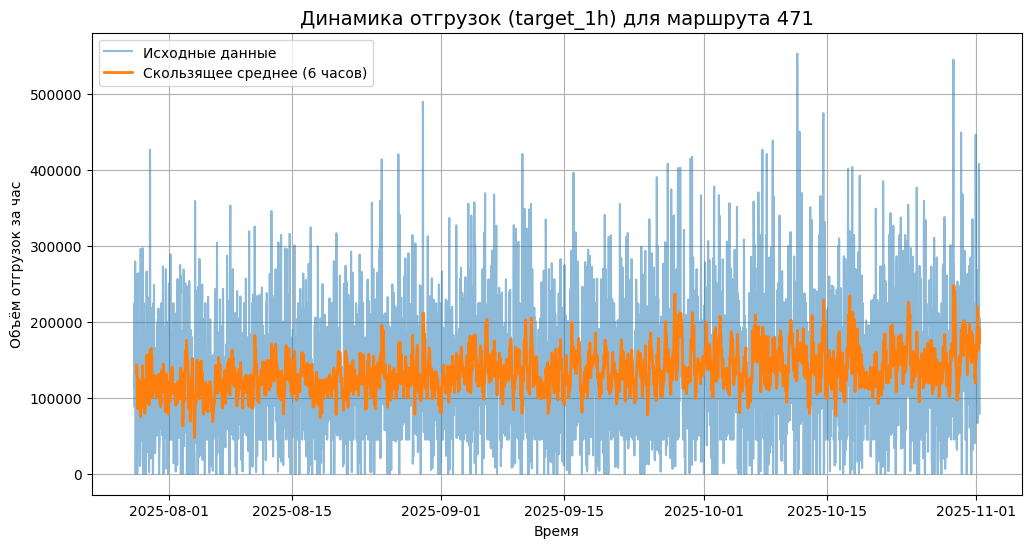

In [9]:
route_example = train_df[train_df['route_id'] == 471].copy()

plt.figure(figsize=(12, 6))
plt.plot(route_example['timestamp'], route_example['target_1h'], alpha=0.5, label='Исходные данные')
plt.plot(route_example['timestamp'], route_example['target_1h'].rolling(window=12).mean(), linewidth=2, label='Скользящее среднее (6 часов)')
plt.title('Динамика отгрузок (target_1h) для маршрута 471', fontsize=14)
plt.xlabel('Время')
plt.ylabel('Объём отгрузок за час')
plt.legend()
plt.grid(True)

---
**Выводы:**

Данные шумные - на графике динамики `target_1h` видны резкие скачки и колебания. Это характерно для временных рядов с высокой волатильностью.

Для прогнозирования таких временных рядов простые статистические модели (SARIMA, экспоненциальное сглаживание) могут оказаться неэффективными из-за сильного шума и нестационарности

---

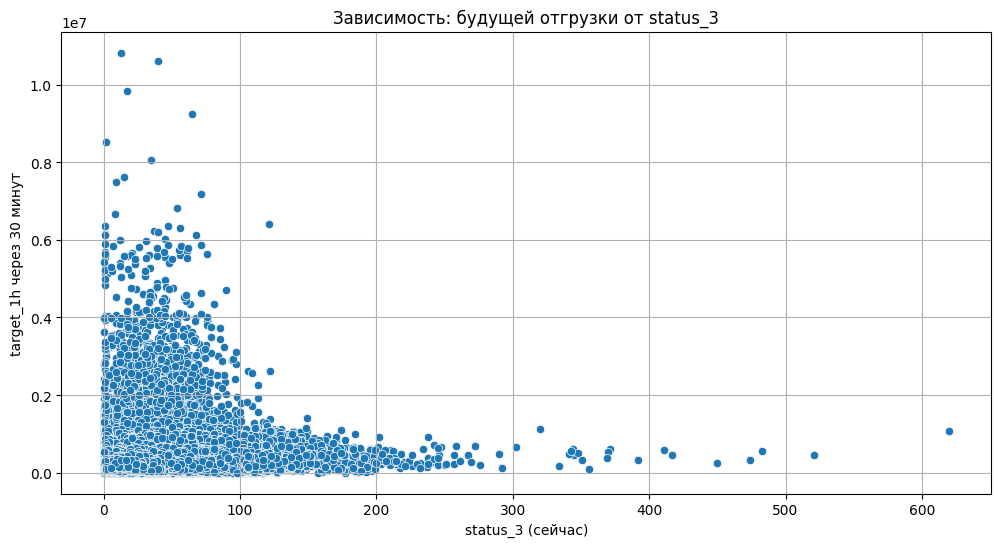

In [10]:
train_df['target_next'] = train_df['target_1h'].shift(1)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=train_df, x='status_3', y='target_next')
plt.title('Зависимость: будущей отгрузки от status_3')
plt.xlabel('status_3 (сейчас)')
plt.ylabel('target_1h через 30 минут')
plt.grid()

---
**Выводы:**

- Высокие значения `status_3` встречаются редко и не приводят к высоким отгрузкам
- Зависимость нелинейная и ограниченная

---

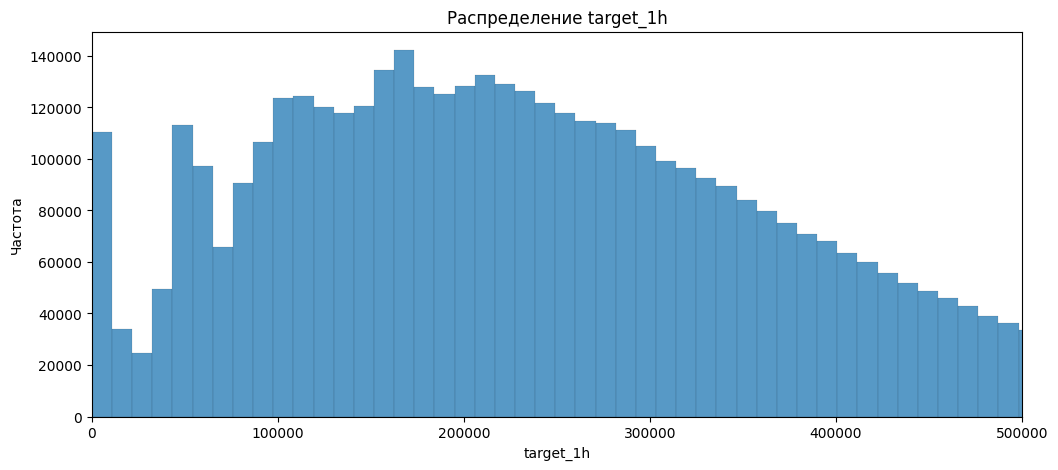

In [11]:
plt.figure(figsize=(12, 5))
sns.histplot(train_df['target_1h'], bins=1000)
plt.xlim(0, 500000)
plt.title('Распределение target_1h')
plt.xlabel('target_1h')
plt.ylabel('Частота');

---
**Вывод:**

- Распределение сильно скошено вправо (большинство значений в районе 0-500 000, но есть редкие выбросы до 10 млн)
- Модель должна быть устойчива к выбросам. Можно использовать метрики типа MAE или WAPE, которые не так сильно штрафуют за выбросы, как MSE

---

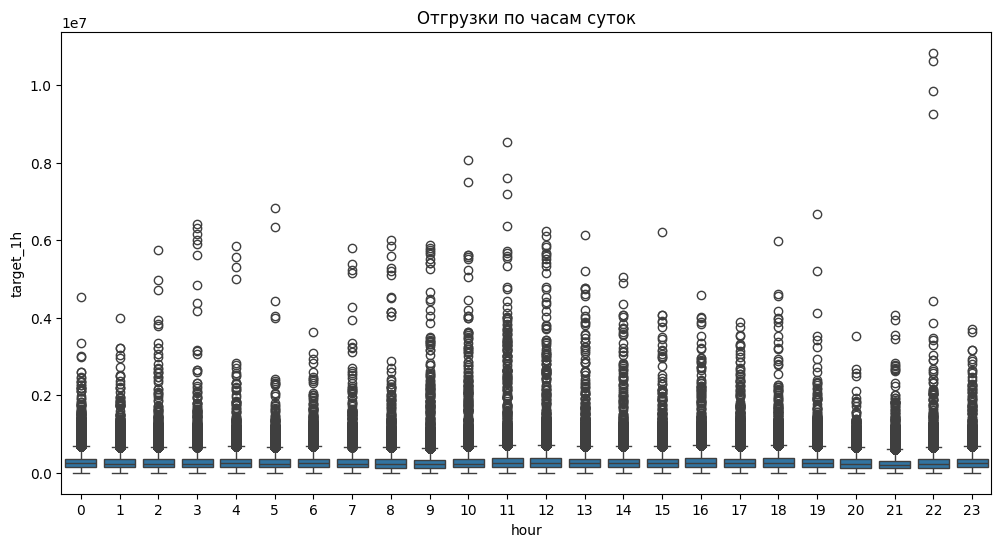

In [12]:
train_df['hour'] = train_df['timestamp'].dt.hour
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x='hour', y='target_1h')
plt.title('Отгрузки по часам суток');

---
**Вывод:**

Распределение отгрузок по часам суток практически не меняется. Час не является значимым признаком для прогнозирования

---

In [13]:
train_df = train_df.drop(['target_next', 'hour'], axis=1)

# 3. Генерируем будущие таргеты 

Для обучения модели предсказывать отгрузки на 8 шагов вперёд (от 30 минут до 4 часов) создаём новые колонки:

- `target_step_1` - значение `target_1h` через 30 минут
- `target_step_2` - через 1 час
- ...
- `target_step_8` - через 4 часа

Сдвиг выполняется в рамках каждого маршрута (`route_id`) отдельно

In [14]:
route_group = train_df.groupby('route_id')

for step in range(1, 9):
    train_df[f'target_step_{step}'] = route_group['target_1h'].shift(-step)
    

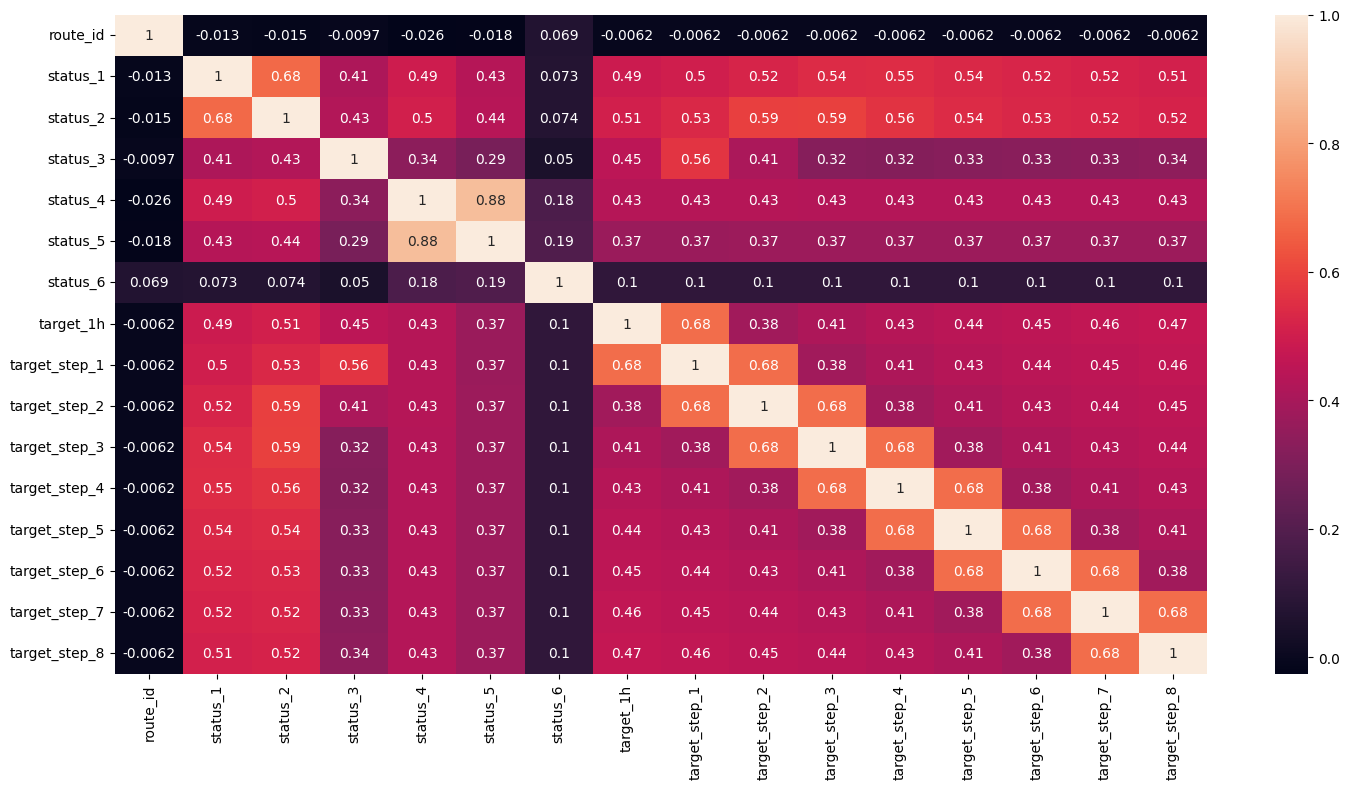

In [15]:
plt.figure(figsize=(15, 8))
sns.heatmap(data=train_df.corr(numeric_only=True), annot=True)
plt.tight_layout()

# 4. Feature Engineering 

### Лаги целевой переменной (смотрим на предыдущие target_1h)

In [16]:
for lag in range(1, 11):
    train_df[f'target_lag_{lag}'] = train_df.groupby('route_id')['target_1h'].shift(lag)

### Скользящие средние статусов 

In [17]:
statuses = ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']

In [18]:
for status in statuses:
    train_df[f'rolling_mean_{status}_6'] = train_df.groupby('route_id')[status].shift(1).rolling(window=6).mean()
    train_df[f'rolling_mean_{status}_12'] = train_df.groupby('route_id')[status].shift(1).rolling(window=12).mean()

### Лаги статусов (смотрим на предыдуще статусы)

In [19]:
for status in statuses:
    train_df[f'{status}_lag1'] = train_df.groupby('route_id')[status].shift(1)
    train_df[f'{status}_lag2'] = train_df.groupby('route_id')[status].shift(2)
    train_df[f'{status}_lag3'] = train_df.groupby('route_id')[status].shift(3)

### Разница статусов

In [20]:
for status in statuses:
    train_df[f'{status}_diff1'] = train_df.groupby('route_id')[status].diff(1)
    train_df[f'{status}_diff2'] = train_df.groupby('route_id')[status].diff(2)

### Сумма статусов 1, 2, 3 и сумма статусов 4, 5, 6

Может быть, отгрузка зависит от общего объёма

In [21]:
train_df['total_status_1-3'] = train_df['status_1'] + train_df['status_2'] + train_df['status_3']
train_df['total_status_4-6'] = train_df['status_4'] + train_df['status_5'] + train_df['status_6']

In [22]:
# Сохраняем последние строки для предсказания (тестовая выборка)
# После генерации признаков удаляем строки с NaN 
last_str = train_df.groupby('route_id').last().reset_index()
last_str = last_str.drop(['target_step_1', 'target_step_2', 'target_step_3', 'target_step_4', 'target_step_5', 'target_step_6', 'target_step_7', 'target_step_8'], axis=1)

In [23]:
train_df = train_df.dropna()

# 5. Разделение на Train и Test

In [24]:
from datetime import timedelta

In [25]:
X_train_list, y_train_list, X_test_list, y_test_list = [], [], [], []
feature_cols = [col for col in train_df.columns if col not in ['target_1h'] + [f'target_step_{step}' for step in range(1, 9)]]

for route in train_df['route_id'].unique():
    data = train_df[train_df['route_id'] == route].sort_values('timestamp')
    
    X_train_list.append(data.iloc[:-9][feature_cols])
    y_train_list.append(data.iloc[:-9][[f'target_step_{step}' for step in range(1, 9)]])
    
    X_test_list.append(data.iloc[-9:-8][feature_cols])
    y_test_list.append(data.iloc[-8:]['target_1h'].values)

In [26]:
X_train = pd.concat(X_train_list)
y_train = pd.concat(y_train_list)
X_test = pd.concat(X_test_list)
y_test = np.array(y_test_list) 

In [27]:
X_test = X_test.drop('timestamp', axis=1)

# 6. Сравнение качества модели на разных временных окнах (7, 14, 21 день)

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge

In [51]:
class WapePlusRbias:
    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias

metric = WapePlusRbias()

In [52]:
numeric_features = [f for f in X_train.columns if f != 'route_id' and f != 'timestamp']
categorical_features = ['route_id']

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), 
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

In [55]:
pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [56]:
results = {}
for days in [7, 14, 21]:
    print(f'\n--- {days} дней ---')
    
    start = X_train['timestamp'].max() - timedelta(days=days)
    X_train_cur = X_train[X_train['timestamp'] > start].copy()
    y_train_cur = y_train.loc[X_train_cur.index]
    X_train_cur = X_train_cur.drop('timestamp', axis=1)
    
    pipeline_ridge.fit(X_train_cur, y_train_cur)
    y_pred = pipeline_ridge.predict(X_test)
    score = metric.calculate(y_test.flatten(), y_pred.flatten())
    results[days] = score
    print(f'Ridge {days} дней: {score}')


--- 7 дней ---
Ridge 7 дней: 0.3368191817890889

--- 14 дней ---
Ridge 14 дней: 0.3390081478170153

--- 21 дней ---
Ridge 21 дней: 0.3398761806248392


---
**Вывод:**

Наилучший результат показало окно в **7 дней** (скор 0.3368)

Дальнейшее увеличение окна до 14 или 21 дня не улучшает качество, а даже ухудшает его

---

# 7. Финальный сабмит (Ridge, 7 дней)

Обучаем модель на последних 7 днях из train_df, делаем предсказание для test_df, сохраняем результат

In [65]:
from datetime import timedelta

In [66]:
n_days = 7
last_date = last_str['timestamp'].max()
train_start = last_date - timedelta(days=n_days)

In [67]:
train_filtered  = train_df[train_df['timestamp'] >= train_start]

In [68]:
feature_cols = [col for col in train_filtered.columns if col not in ['timestamp', 'target_1h'] + [f'target_step_{step}' for step in range(1, 9)]]

In [69]:
X_train_submit = train_filtered[feature_cols]
y_train_submit = train_filtered[[f'target_step_{step}' for step in range(1, 9)]]

In [70]:
X_test_submit = last_str.drop(['timestamp', 'target_1h'], axis=1)

In [71]:
pipeline_ridge.fit(X_train_submit, y_train_submit)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
y_pred_submit = pipeline_ridge.predict(X_test_submit)

In [73]:
test_pred_df = pd.DataFrame(
    y_pred_submit,
    columns=[f'target_step_{step}' for step in range(1, 9)],
    index=X_test_submit.index
)
test_pred_df['route_id'] = X_test_submit['route_id'].values

In [75]:
forecast_df = test_pred_df.melt(
    id_vars='route_id',
    value_vars=[f'target_step_{step}' for step in range(1, 9)],
    var_name='step',
    value_name='forecast'
)

In [76]:
forecast_df['step_num'] = forecast_df['step'].str.extract(r'(\d+)').astype(int)
forecast_df['timestamp'] = last_date + pd.to_timedelta(forecast_df['step_num'] * 30, unit='m')

In [77]:
submission = test_df.merge(
    forecast_df[['route_id', 'timestamp', 'forecast']],
    on=['route_id', 'timestamp'],
    how='left'
)[['id', 'forecast']]
submission = submission.rename(columns={'forecast': 'y_pred'})

In [79]:
submission.to_csv('submission_ridge_7days.csv', index=False)